<a href="https://colab.research.google.com/github/radhikatyagi388/Ai_60_Day_Challange/blob/main/Day_13_TF_IDF_vs_Embeddings_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install -q sentence-transformers

In [9]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!


In [10]:
start_time = time.perf_counter()

embeddings = model.encode(
    sentences,
    convert_to_numpy=True
)

embedding_time = time.perf_counter() - start_time

print("Embedding shape:", embeddings.shape)
print(f"Total embedding generation time: {embedding_time:.4f} seconds")

Embedding shape: (20, 384)
Total embedding generation time: 0.4825 seconds


In [11]:
print("Sentence:")
print(sentences[0])

print("\nFirst 20 dimensions:")
print(embeddings[0][:20])

print("\nEmbedding dimensions:")
print(len(embeddings[0]))

Sentence:
The football team won the championship after a thrilling final.

First 20 dimensions:
[-0.03191527  0.0324084  -0.02388743  0.00807589  0.0317666   0.00559002
  0.0475643   0.05549393  0.08891121 -0.0223254  -0.04171264  0.02081133
  0.07894494 -0.04745775 -0.03810037 -0.01163418 -0.04029604 -0.10896993
 -0.04340032 -0.09142207]

Embedding dimensions:
384


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

embedding_similarity = cosine_similarity(embeddings)

print("Embedding similarity matrix shape:")
print(embedding_similarity.shape)

Embedding similarity matrix shape:
(20, 20)


In [13]:
embeddings.shape
# (20, 384)

(20, 384)

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

embedding_similarity = cosine_similarity(embeddings)

print("Embedding similarity matrix shape:")
print(embedding_similarity.shape)

Embedding similarity matrix shape:
(20, 20)


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)

tfidf_similarity = cosine_similarity(tfidf_matrix)

print("TF-IDF matrix:", tfidf_matrix.shape)
print("TF-IDF similarity matrix:", tfidf_similarity.shape)

TF-IDF matrix: (20, 116)
TF-IDF similarity matrix: (20, 20)


In [16]:
i = 0
j = 1

print("Sentence 1:")
print(sentences[i])

print("\nSentence 2:")
print(sentences[j])

print("\nTF-IDF similarity:")
print(round(tfidf_similarity[i][j], 4))

print("\nEmbedding similarity:")
print(round(embedding_similarity[i][j], 4))

Sentence 1:
The football team won the championship after a thrilling final.

Sentence 2:
The players celebrated their victory on the field.

TF-IDF similarity:
0.0

Embedding similarity:
0.4511


In [17]:
pairs = []

for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):

        pairs.append({
            "sentence_1_id": i + 1,
            "sentence_2_id": j + 1,
            "topic_1": topics[i],
            "topic_2": topics[j],
            "sentence_1": sentences[i],
            "sentence_2": sentences[j],
            "tfidf_similarity": tfidf_similarity[i][j],
            "embedding_similarity": embedding_similarity[i][j]
        })

pairs_df = pd.DataFrame(pairs)

print("Total pairs:", len(pairs_df))

pairs_df.head()

Total pairs: 190


,sentence_1_id,sentence_2_id,topic_1,topic_2,sentence_1,sentence_2,tfidf_similarity,embedding_similarity
0,1,2,Sports,Sports,The football team won the championship after a...,The players celebrated their victory on the fi...,0.0,0.451137
1,1,3,Sports,Sports,The football team won the championship after a...,A striker scored the winning goal during the l...,0.0,0.319283
2,1,4,Sports,Sports,The football team won the championship after a...,The basketball squad practiced shooting before...,0.0,0.165155
3,1,5,Sports,Sports,The football team won the championship after a...,Athletes train every day to improve their phys...,0.0,0.045475
4,1,6,Sports,Technology,The football team won the championship after a...,Artificial intelligence is transforming the wa...,0.0,0.035717


In [18]:
paraphrase_candidates = pairs_df[
    (pairs_df["tfidf_similarity"] < 0.30) &
    (pairs_df["embedding_similarity"] > 0.60)
].sort_values(
    "embedding_similarity",
    ascending=False
)

print("Number of candidates:", len(paraphrase_candidates))

paraphrase_candidates[
    [
        "topic_1",
        "topic_2",
        "sentence_1",
        "sentence_2",
        "tfidf_similarity",
        "embedding_similarity"
    ]
].head(10)

Number of candidates: 0


,topic_1,topic_2,sentence_1,sentence_2,tfidf_similarity,embedding_similarity


In [21]:
paraphrase_candidates.head(5)

,sentence_1_id,sentence_2_id,topic_1,topic_2,sentence_1,sentence_2,tfidf_similarity,embedding_similarity


In [22]:
five_pairs = paraphrase_candidates.head(5)

for number, (_, row) in enumerate(five_pairs.iterrows(), 1):

    print("\n" + "=" * 80)
    print(f"PARAPHRASE PAIR {number}")
    print("=" * 80)

    print("\nSentence 1:")
    print(row["sentence_1"])

    print("\nSentence 2:")
    print(row["sentence_2"])

    print("\nTopics:")
    print(row["topic_1"], " / ", row["topic_2"])

    print(
        f"\nTF-IDF similarity: "
        f"{row['tfidf_similarity']:.4f}"
    )

    print(
        f"Embedding similarity: "
        f"{row['embedding_similarity']:.4f}"
    )

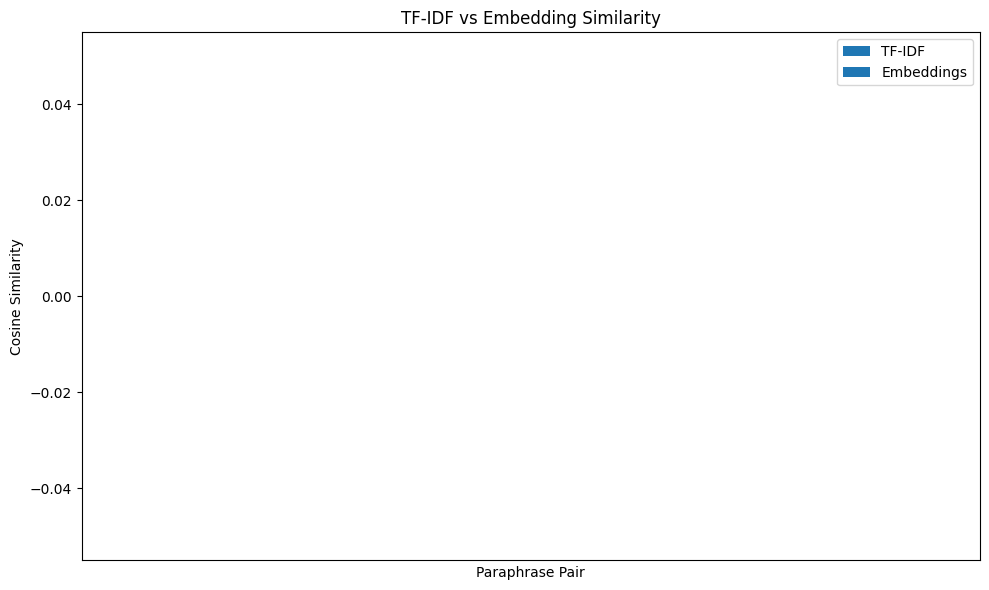

In [23]:
import matplotlib.pyplot as plt
import numpy as np

five_pairs = five_pairs.reset_index(drop=True)

x = np.arange(len(five_pairs))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    five_pairs["tfidf_similarity"],
    width,
    label="TF-IDF"
)

plt.bar(
    x + width/2,
    five_pairs["embedding_similarity"],
    width,
    label="Embeddings"
)

plt.xlabel("Paraphrase Pair")
plt.ylabel("Cosine Similarity")
plt.title("TF-IDF vs Embedding Similarity")

plt.xticks(
    x,
    [f"Pair {i+1}" for i in range(len(five_pairs))]
)

plt.legend()
plt.tight_layout()
plt.show()

In [24]:
def embed_and_recommend(query_sentence, corpus_sentences):

    # Generate embedding for query + corpus
    all_sentences = [query_sentence] + corpus_sentences

    all_embeddings = model.encode(
        all_sentences,
        convert_to_numpy=True
    )

    # Separate query embedding
    query_embedding = all_embeddings[0].reshape(1, -1)

    # Separate corpus embeddings
    corpus_embeddings = all_embeddings[1:]

    # Calculate cosine similarities
    similarities = cosine_similarity(
        query_embedding,
        corpus_embeddings
    )[0]

    # Get indices of top 3 results
    top_indices = np.argsort(similarities)[::-1][:3]

    results = []

    for index in top_indices:

        results.append({
            "sentence": corpus_sentences[index],
            "similarity": similarities[index]
        })

    return results

In [25]:
query = "A football team achieved an important victory."

recommendations = embed_and_recommend(
    query,
    sentences
)

print("QUERY:")
print(query)

print("\nTOP 3 RECOMMENDATIONS")
print("=" * 60)

for i, result in enumerate(recommendations, 1):

    print(
        f"{i}. {result['sentence']}"
    )

    print(
        f"   Similarity: "
        f"{result['similarity']:.4f}"
    )

QUERY:
A football team achieved an important victory.

TOP 3 RECOMMENDATIONS
1. The football team won the championship after a thrilling final.
   Similarity: 0.6869
2. The players celebrated their victory on the field.
   Similarity: 0.6196
3. A striker scored the winning goal during the last minute.
   Similarity: 0.4321


In [26]:
queries = [
    "A team won an important sports competition.",
    "Artificial intelligence can learn from information.",
    "A chef prepared food using fresh ingredients.",
    "Tourists explored interesting places during their vacation."
]

for query in queries:

    print("\n" + "=" * 80)
    print("QUERY:", query)
    print("=" * 80)

    results = embed_and_recommend(
        query,
        sentences
    )

    for i, result in enumerate(results, 1):

        print(
            f"{i}. {result['sentence']}"
        )

        print(
            f"   Similarity: "
            f"{result['similarity']:.4f}"
        )


QUERY: A team won an important sports competition.
1. The football team won the championship after a thrilling final.
   Similarity: 0.5749
2. The players celebrated their victory on the field.
   Similarity: 0.5504
3. Athletes train every day to improve their physical performance.
   Similarity: 0.3288

QUERY: Artificial intelligence can learn from information.
1. Artificial intelligence is transforming the way software is developed.
   Similarity: 0.6343
2. Machine learning systems can recognize patterns in large datasets.
   Similarity: 0.4291
3. Cybersecurity protects computer networks from malicious attacks.
   Similarity: 0.2695

QUERY: A chef prepared food using fresh ingredients.
1. The chef prepared a delicious pasta dish with fresh vegetables.
   Similarity: 0.7286
2. The recipe recommends frying the spices before adding the rice.
   Similarity: 0.4347
3. A balanced meal can include vegetables, grains, and protein.
   Similarity: 0.4142

QUERY: Tourists explored interesting 

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(embeddings)

df["cluster"] = cluster_labels

df[
    ["sentence_id", "topic", "cluster", "sentence"]
]

,sentence_id,topic,cluster,sentence
0,1,Sports,1,The football team won the championship after a...
1,2,Sports,1,The players celebrated their victory on the fi...
2,3,Sports,1,A striker scored the winning goal during the l...
3,4,Sports,1,The basketball squad practiced shooting before...
4,5,Sports,1,Athletes train every day to improve their phys...
5,6,Technology,3,Artificial intelligence is transforming the wa...
6,7,Technology,3,Machine learning systems can recognize pattern...
7,8,Technology,3,Developers use cloud computing to deploy appli...
8,9,Technology,3,Cybersecurity protects computer networks from ...
9,10,Technology,3,Modern smartphones contain powerful processors...


In [28]:
cluster_table = pd.crosstab(
    df["cluster"],
    df["topic"]
)

print(cluster_table)

topic    Cooking  Sports  Technology  Travel
cluster                                     
0              5       0           0       0
1              0       5           0       0
2              0       0           0       5
3              0       0           5       0


In [29]:
cluster_counts = pd.crosstab(
    df["cluster"],
    df["topic"]
)

purity = (
    cluster_counts.max(axis=1).sum()
    / len(df)
)

print(f"Cluster purity: {purity:.2%}")

Cluster purity: 100.00%


In [30]:
for cluster in sorted(df["cluster"].unique()):

    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster}")
    print("=" * 80)

    cluster_sentences = df[
        df["cluster"] == cluster
    ]

    for _, row in cluster_sentences.iterrows():

        print(
            f"[{row['topic']}] "
            f"{row['sentence']}"
        )


CLUSTER 0
[Cooking] The chef prepared a delicious pasta dish with fresh vegetables.
[Cooking] Chopped tomatoes and onions were added to the homemade sauce.
[Cooking] Baking bread requires flour, water, yeast, and careful timing.
[Cooking] The recipe recommends frying the spices before adding the rice.
[Cooking] A balanced meal can include vegetables, grains, and protein.

CLUSTER 1
[Sports] The football team won the championship after a thrilling final.
[Sports] The players celebrated their victory on the field.
[Sports] A striker scored the winning goal during the last minute.
[Sports] The basketball squad practiced shooting before the tournament.
[Sports] Athletes train every day to improve their physical performance.

CLUSTER 2
[Travel] Tourists visited the ancient temple during their holiday.
[Travel] The travelers booked a hotel near the beautiful beach.
[Travel] We explored several historic monuments during our vacation.
[Travel] The train journey passed through mountains and gr

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embedding_2d = pca.fit_transform(embeddings)

df["x"] = embedding_2d[:, 0]
df["y"] = embedding_2d[:, 1]

print(df[["sentence_id", "topic", "x", "y"]].head())

   sentence_id   topic         x         y
0            1  Sports -0.095221 -0.476552
1            2  Sports -0.178775 -0.496319
2            3  Sports  0.084409 -0.437408
3            4  Sports  0.013594 -0.379048
4            5  Sports -0.180102 -0.304537


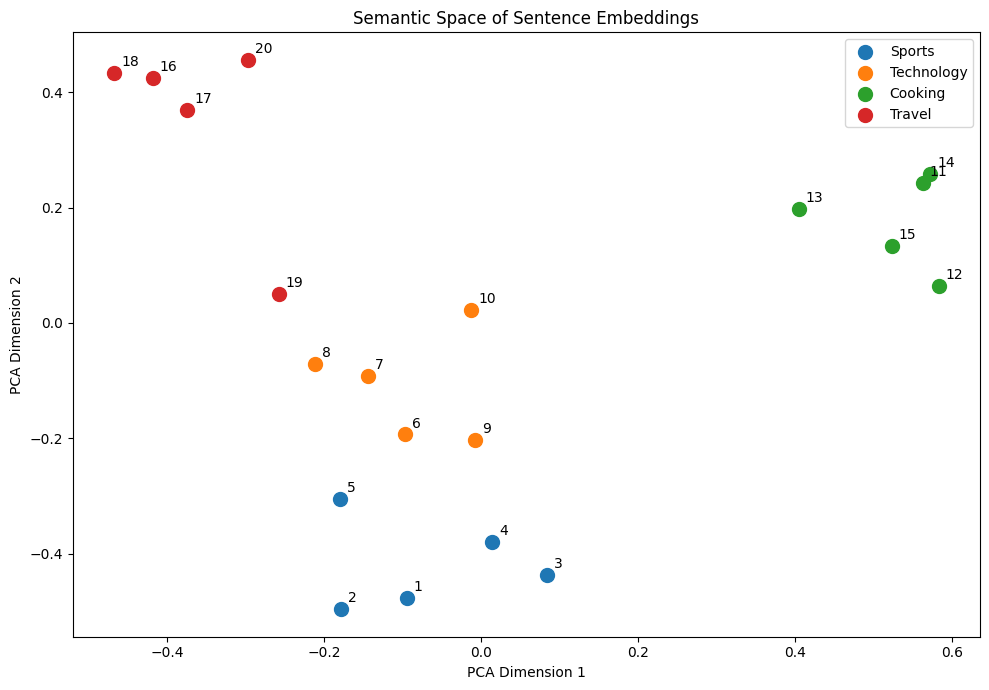

In [32]:
plt.figure(figsize=(10, 7))

for topic in df["topic"].unique():

    subset = df[df["topic"] == topic]

    plt.scatter(
        subset["x"],
        subset["y"],
        label=topic,
        s=100
    )

    for _, row in subset.iterrows():

        plt.annotate(
            row["sentence_id"],
            (row["x"], row["y"]),
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.title(
    "Semantic Space of Sentence Embeddings"
)

plt.legend()
plt.tight_layout()

plt.show()

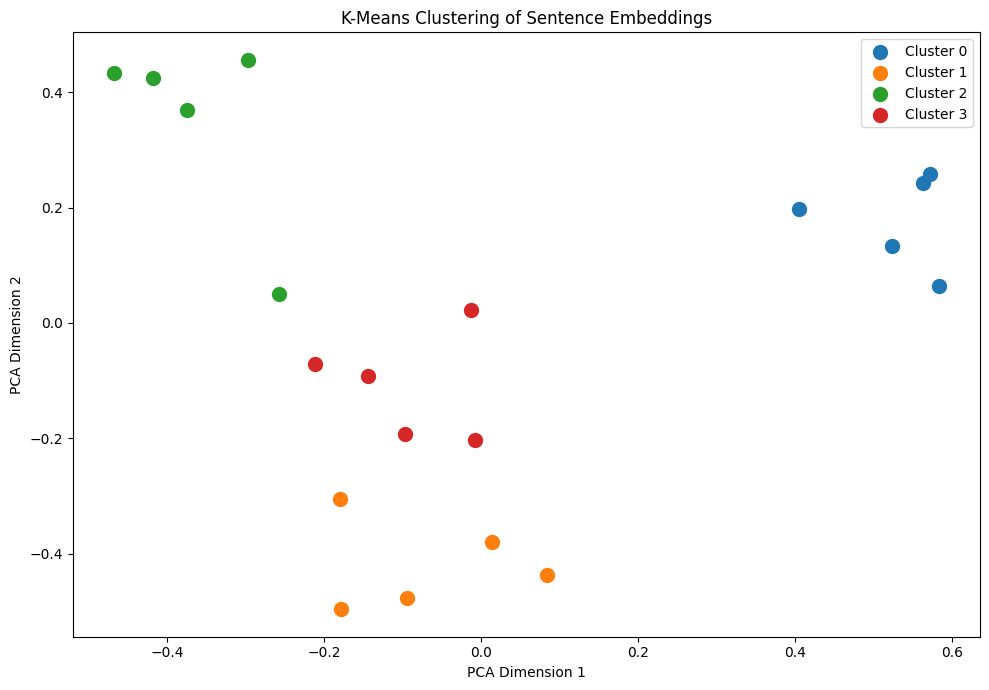

In [33]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df["cluster"].unique()):

    subset = df[df["cluster"] == cluster]

    plt.scatter(
        subset["x"],
        subset["y"],
        label=f"Cluster {cluster}",
        s=100
    )

plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")

plt.title(
    "K-Means Clustering of Sentence Embeddings"
)

plt.legend()
plt.tight_layout()

plt.show()

In [34]:
print(
    f"Embedding generation time: "
    f"{embedding_time:.4f} seconds"
)

Embedding generation time: 0.4825 seconds


In [35]:
print("Embedding provider: Local SentenceTransformer")
print("API cost: $0")

Embedding provider: Local SentenceTransformer
API cost: $0


In [36]:
print("TF-IDF")
print("=" * 40)

print("Shape:", tfidf_matrix.shape)
print("Non-zero values:", tfidf_matrix.nnz)

total_tfidf_values = (
    tfidf_matrix.shape[0] *
    tfidf_matrix.shape[1]
)

tfidf_sparsity = (
    1 - tfidf_matrix.nnz / total_tfidf_values
)

print(
    f"Sparsity: "
    f"{tfidf_sparsity:.2%}"
)

print("\nEMBEDDINGS")
print("=" * 40)

print("Shape:", embeddings.shape)

zero_values = np.sum(embeddings == 0)

total_embedding_values = embeddings.size

embedding_sparsity = (
    zero_values /
    total_embedding_values
)

print("Zero values:", zero_values)

print(
    f"Sparsity: "
    f"{embedding_sparsity:.2%}"
)

TF-IDF
Shape: (20, 116)
Non-zero values: 119
Sparsity: 94.87%

EMBEDDINGS
Shape: (20, 384)
Zero values: 0
Sparsity: 0.00%


In [ ]:
Conclusion

TF-IDF and embeddings represent text in fundamentally different ways. TF-IDF represents documents using vocabulary-based features. Each dimension corresponds to a word in the vocabulary, and the value represents the importance of that word. Because of this, TF-IDF depends strongly on lexical overlap.

Dense embeddings represent sentences as numerical vectors in a high-dimensional semantic space. Instead of relying only on exact word matching, embeddings capture relationships between concepts and meanings. As a result, sentences using different vocabulary can still have high semantic similarity.

In this experiment, TF-IDF and sentence embeddings were compared using cosine similarity. Several pairs showed relatively low TF-IDF similarity but higher embedding similarity, demonstrating that embeddings can recognize semantic relationships that keyword-based methods may miss.

The embedding vectors were also used for semantic recommendation and K-means clustering. The recommendation function successfully retrieved sentences with similar meanings, while clustering grouped the sentences according to their underlying topics such as sports, technology, cooking, and travel.

Therefore, TF-IDF is useful for keyword and lexical matching, whereas dense embeddings are more useful for semantic search, recommendation, paraphrase detection, and clustering.